# Orthogonal Trajectories

## Real-World Scenario: Heat Flow in a Biofilm

In whole cell modeling, biofilms grow on surfaces where temperature gradients drive metabolic activity. The **isotherms** (curves of constant temperature) and the **heat flow lines** (curves along which heat flows) form two families of curves that are everywhere **perpendicular** to each other.

This is an example of **orthogonal trajectories**: given one family of curves, find a second family that intersects the first at right angles everywhere.

Section 1.6 of AEM develops the method:

1. Start with a **one-parameter family** of curves $G(x, y, c) = 0$
2. **Differentiate** to find the ODE of the family (eliminating the parameter $c$)
3. **Replace** $y'$ with $-1/y'$ to get the ODE of the orthogonal trajectories
4. **Solve** the new ODE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.integrate import solve_ivp

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## 1. The Method — Ellipses and Parabolas

Consider the family of ellipses from the textbook (Eq. 1):

$$\tfrac{1}{2}x^2 + y^2 = c \qquad (c > 0)$$

These could represent **equipotential curves** (surfaces of equal voltage) between two elliptic cylinders in an electric field.

### Step 1 — Find the ODE of the given family

Differentiate implicitly with respect to $x$ to eliminate $c$:

$$x + 2y\,y' = 0 \quad \Longrightarrow \quad y' = f(x,y) = -\frac{x}{2y}$$

### Step 2 — ODE of the orthogonal trajectories

At any intersection point, the given curve has slope $f$. The orthogonal trajectory must have slope $-1/f$ (since perpendicular lines satisfy $m_1 \cdot m_2 = -1$):

$$\tilde{y}' = -\frac{1}{f(x,\tilde{y})} = +\frac{2\tilde{y}}{x}$$

### Step 3 — Solve by separating variables

$$\frac{d\tilde{y}}{\tilde{y}} = \frac{2\,dx}{x} \quad \Longrightarrow \quad \ln|\tilde{y}| = 2\ln|x| + C \quad \Longrightarrow \quad \boxed{\tilde{y} = c^* x^2}$$

The orthogonal trajectories are **parabolas** — the paths along which charged particles would move in the electric field.

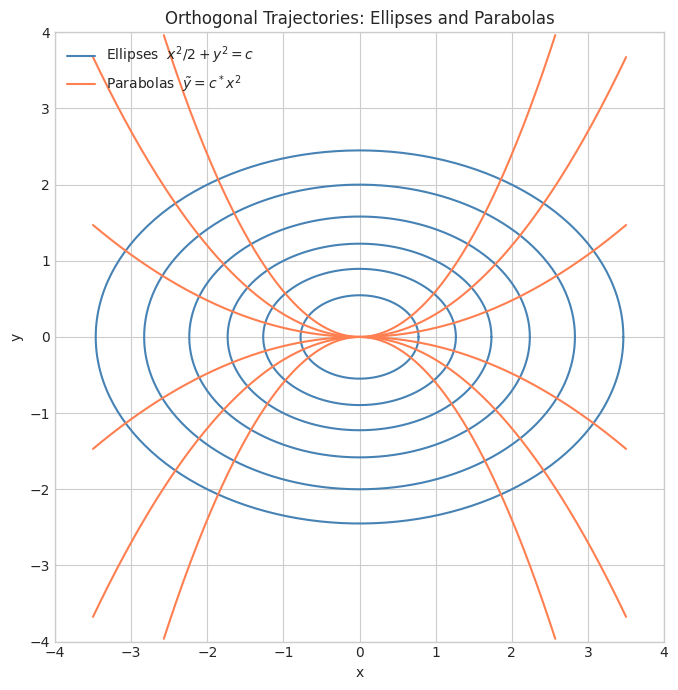

In [2]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

theta = np.linspace(0, 2 * np.pi, 300)
x_dense = np.linspace(-3.5, 3.5, 400)

# Ellipses: x²/2 + y² = c
for c in [0.3, 0.8, 1.5, 2.5, 4.0, 6.0]:
    a = np.sqrt(2 * c)  # semi-axis along x
    b = np.sqrt(c)       # semi-axis along y
    xe = a * np.cos(theta)
    ye = b * np.sin(theta)
    label = 'Ellipses  $x^2/2 + y^2 = c$' if c == 0.3 else None
    ax.plot(xe, ye, color='steelblue', lw=1.5, label=label)

# Parabolas: y = c* x²
for cstar in [-0.6, -0.3, -0.12, 0.12, 0.3, 0.6]:
    yp = cstar * x_dense**2
    mask = np.abs(yp) < 4
    label = 'Parabolas  $\\tilde{y} = c^* x^2$' if cstar == -0.6 else None
    ax.plot(x_dense[mask], yp[mask], color='coral', lw=1.5, label=label)

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Orthogonal Trajectories: Ellipses and Parabolas')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 2. Verifying Orthogonality Numerically

At any point $(x_0, y_0)$, the slopes of the ellipse and the parabola passing through that point should satisfy:

$$m_{\text{ellipse}} \cdot m_{\text{parabola}} = -1$$

- Ellipse slope: $m_1 = -x_0 / (2y_0)$
- Parabola slope: $m_2 = 2y_0 / x_0$

Product: $m_1 \cdot m_2 = \dfrac{-x_0}{2y_0} \cdot \dfrac{2y_0}{x_0} = -1 \;\checkmark$

In [3]:
# Verify at several random points
rng = np.random.default_rng(42)
test_points = rng.uniform(-3, 3, size=(6, 2))
# Avoid points too close to axes
test_points = test_points[np.abs(test_points).min(axis=1) > 0.3]

print(f'{"Point (x, y)":>20s}   {"m_ellipse":>10s}   {"m_parab":>10s}   {"product":>10s}')
print('-' * 60)
for x0, y0 in test_points:
    m1 = -x0 / (2 * y0)
    m2 = 2 * y0 / x0
    print(f'  ({x0:+5.2f}, {y0:+5.2f})   {m1:10.4f}   {m2:10.4f}   {m1 * m2:10.4f}')

        Point (x, y)    m_ellipse      m_parab      product
------------------------------------------------------------
  (+1.64, -0.37)       2.2411      -0.4462      -1.0000
  (+2.15, +1.18)      -0.9084       1.1008      -1.0000
  (-2.43, +2.85)       0.4266      -2.3440      -1.0000
  (+1.57, +1.72)      -0.4564       2.1909      -1.0000
  (-0.78, +2.56)       0.1514      -6.6062      -1.0000


## 3. Biotech Application: Isotherms and Heat Flow in a Biofilm

Consider a simplified model where the temperature distribution in a biofilm near a heated surface is described by concentric circles:

$$x^2 + y^2 = c \qquad (\text{isotherms})$$

**Step 1** — Differentiate: $2x + 2y\,y' = 0 \Longrightarrow y' = -x/y$

**Step 2** — Orthogonal trajectories ODE: $\tilde{y}' = y/x$

**Step 3** — Solve: $d\tilde{y}/\tilde{y} = dx/x \Longrightarrow \tilde{y} = c^* x$ (straight lines through the origin)

The heat flows **radially** — along straight lines through the origin — perpendicular to the circular isotherms. This is exactly what we expect from physical intuition.

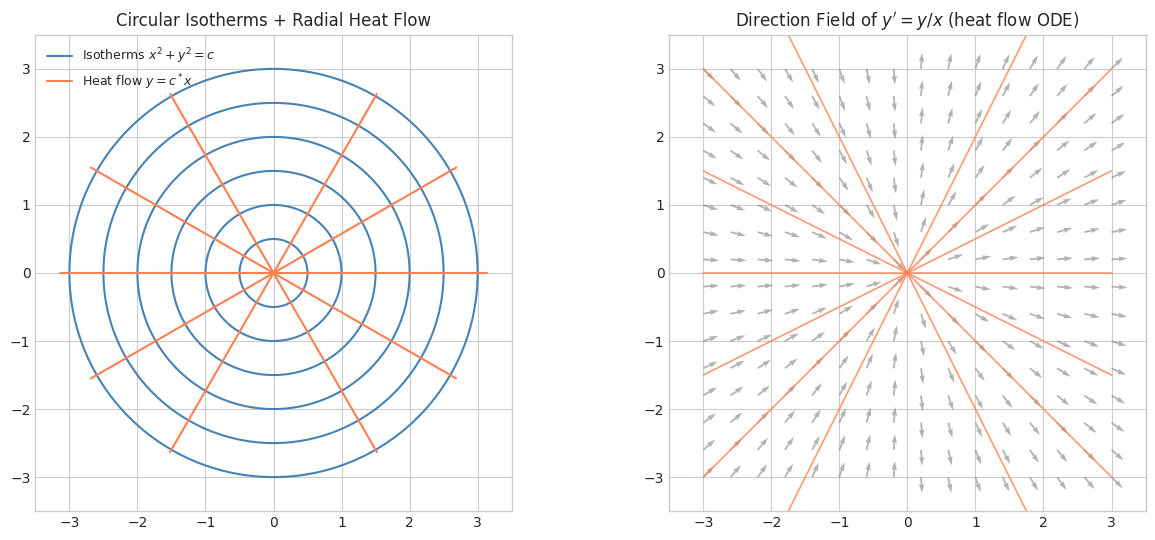

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# --- Left panel: circles and radial lines ---
ax = axes[0]
theta = np.linspace(0, 2 * np.pi, 300)

for r in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    label = 'Isotherms $x^2+y^2=c$' if r == 0.5 else None
    ax.plot(r * np.cos(theta), r * np.sin(theta), 'steelblue', lw=1.5, label=label)

for slope in np.tan(np.linspace(0, np.pi, 7)[:-1]):
    xs = np.linspace(-3.2, 3.2, 100)
    ys = slope * xs
    mask = xs**2 + ys**2 <= 10
    label = 'Heat flow $y=c^*x$' if slope == np.tan(0) else None
    ax.plot(xs[mask], ys[mask], 'coral', lw=1.5, label=label)

ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.5, 3.5)
ax.set_aspect('equal')
ax.set_title('Circular Isotherms + Radial Heat Flow')
ax.legend(loc='upper left', fontsize=9)

# --- Right panel: direction field of the OT ODE ---
ax = axes[1]
xg = np.linspace(-3, 3, 16)
yg = np.linspace(-3, 3, 16)
X, Y = np.meshgrid(xg, yg)

# ODE of orthogonal trajectories: y' = y/x
U = np.ones_like(X)
V = np.where(np.abs(X) > 0.1, Y / X, 0)
norm = np.sqrt(U**2 + V**2)
U /= norm
V /= norm

ax.quiver(X, Y, U, V, color='gray', alpha=0.6, scale=30)

# Overlay some solution curves (trajectories)
for slope in [-2, -1, -0.5, 0, 0.5, 1, 2]:
    xs = np.linspace(-3, 3, 100)
    ys = slope * xs
    ax.plot(xs, ys, 'coral', lw=1.2, alpha=0.8)

ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.5, 3.5)
ax.set_aspect('equal')
ax.set_title("Direction Field of $y' = y/x$ (heat flow ODE)")

plt.tight_layout()
plt.show()

## 4. A Richer Example — Exponential Curves

Consider the family $y = c\,e^{-x^2}$ (Gaussian-shaped curves, common in diffusion problems).

**Step 1** — Eliminate $c$. Since $c = y\,e^{x^2}$, differentiate $y = c\,e^{-x^2}$:

$$y' = -2x\,c\,e^{-x^2} = -2xy$$

**Step 2** — Orthogonal trajectories ODE:

$$\tilde{y}' = \frac{1}{2x\tilde{y}}$$

**Step 3** — Separate and integrate:

$$2\tilde{y}\,d\tilde{y} = \frac{dx}{x} \quad \Longrightarrow \quad \tilde{y}^2 = \ln|x| + C$$

The orthogonal trajectories are curves of the form $\tilde{y} = \pm\sqrt{\ln|x| + C}$.

<>:8: SyntaxWarning: invalid escape sequence '\,'
<>:8: SyntaxWarning: invalid escape sequence '\,'
/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_88747/848487223.py:8: SyntaxWarning: invalid escape sequence '\,'
  label = 'Given: $y = c\, e^{-x^2}$' if c == -2 else None


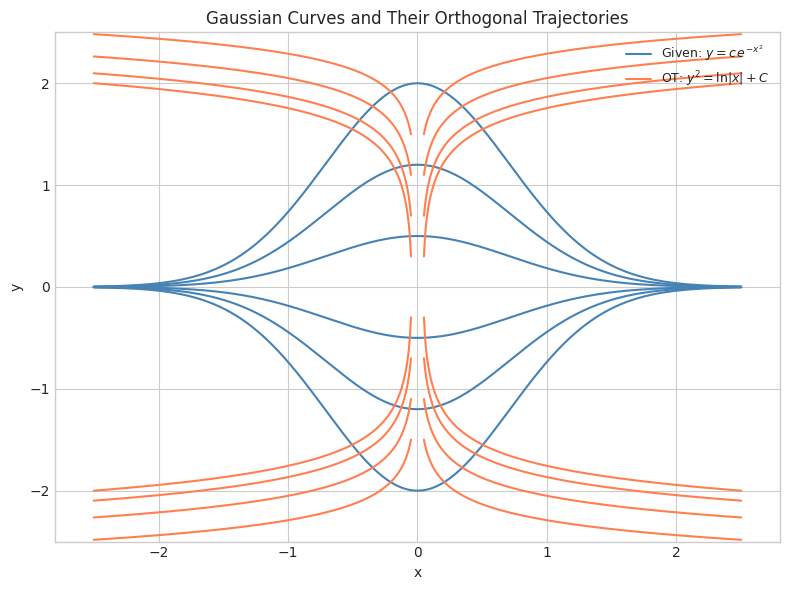

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

x = np.linspace(-2.5, 2.5, 500)

# Given family: y = c * exp(-x²)
for c in [-2, -1.2, -0.5, 0.5, 1.2, 2.0]:
    y = c * np.exp(-x**2)
    label = 'Given: $y = c\, e^{-x^2}$' if c == -2 else None
    ax.plot(x, y, 'steelblue', lw=1.5, label=label)

# Orthogonal trajectories: y² = ln|x| + C
# Use solve_ivp to trace them numerically
def ot_ode(t, y):
    if abs(t) < 1e-10 or abs(y[0]) < 1e-10:
        return [0.0]
    return [1.0 / (2 * t * y[0])]

colors_ot = 'coral'
first = True
for y0 in [0.3, 0.7, 1.1, 1.5]:
    # Trace forward from x = 0.05
    sol_fwd = solve_ivp(ot_ode, [0.05, 2.5], [y0], max_step=0.02, dense_output=True)
    sol_bwd = solve_ivp(ot_ode, [0.05, 2.5], [-y0], max_step=0.02, dense_output=True)
    
    t_plot = np.linspace(0.05, 2.5, 300)
    label = 'OT: $y^2 = \\ln|x| + C$' if first else None
    ax.plot(t_plot, sol_fwd.sol(t_plot)[0], colors_ot, lw=1.5, label=label)
    ax.plot(t_plot, sol_bwd.sol(t_plot)[0], colors_ot, lw=1.5)
    # Mirror for negative x
    ax.plot(-t_plot, sol_fwd.sol(t_plot)[0], colors_ot, lw=1.5)
    ax.plot(-t_plot, sol_bwd.sol(t_plot)[0], colors_ot, lw=1.5)
    first = False

ax.set_xlim(-2.8, 2.8)
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Gaussian Curves and Their Orthogonal Trajectories')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## Summary

| Step | Action | Key Formula |
|------|--------|-------------|
| 1 | Given family $G(x,y,c)=0$ → find its ODE $y' = f(x,y)$ | Differentiate, eliminate $c$ |
| 2 | ODE of orthogonal trajectories | $\tilde{y}' = -1/f(x,\tilde{y})$ |
| 3 | Solve the new ODE | Separation, exact, integrating factor, etc. |

**Physical intuition**: orthogonal trajectories arise naturally whenever two related physical quantities have gradients that are perpendicular — temperature vs. heat flow, electric potential vs. electric field, pressure vs. fluid streamlines.